In [1]:
import warnings
warnings.filterwarnings("ignore")


from pathlib import Path

import numpy as np
import pandas as pd

import scipy.sparse

import joblib


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATA_PATH = Path("../data/processed")
MODEL_PATH = Path("../models")
IMAGE_PATH = Path("../images")

In [3]:
X_train = scipy.sparse.load_npz(
    DATA_PATH / "X_train.npz"
)


X_test = scipy.sparse.load_npz(
    DATA_PATH / "X_test.npz"
)


y_train = np.load(
    DATA_PATH / "y_train.npy"
)


y_test = np.load(
    DATA_PATH / "y_test.npy"
)

In [4]:
X_train.shape, X_test.shape

((5625, 45), (1407, 45))

In [5]:
pd.Series(y_train).value_counts(normalize=True)

0    0.734222
1    0.265778
Name: proportion, dtype: float64

In [6]:
models = {


"Logistic Regression":

LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
),



"Random Forest":

RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
),



"XGBoost":

XGBClassifier(
    n_estimators=300,
    random_state=42,
    eval_metric="logloss"
),



"LightGBM":

LGBMClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    verbose=-1
),



"CatBoost":

CatBoostClassifier(
    iterations=300,
    random_state=42,
    verbose=False,
    auto_class_weights="Balanced"
)

}

In [7]:
results = []

trained_models = {}


for name, model in models.items():

    print(
        f"Training {name}"
    )

    model.fit(
        X_train,
        y_train
    )


    prediction = model.predict(
        X_test
    )


    probability = model.predict_proba(
        X_test
    )[:,1]


    results.append({

        "Model": name,

        "Accuracy":
            accuracy_score(
                y_test,
                prediction
            ),

        "Precision":
            precision_score(
                y_test,
                prediction
            ),

        "Recall":
            recall_score(
                y_test,
                prediction
            ),

        "F1":
            f1_score(
                y_test,
                prediction
            ),

        "ROC_AUC":
            roc_auc_score(
                y_test,
                probability
            )

    })


    trained_models[name] = model

Training Logistic Regression
Training Random Forest
Training XGBoost
Training LightGBM
Training CatBoost


In [8]:
results_df = pd.DataFrame(
    results
)


results_df.sort_values(
    "ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.725657,0.490132,0.796791,0.606925,0.835134
4,CatBoost,0.739872,0.507092,0.764706,0.609808,0.828520
3,LightGBM,0.758351,0.535417,0.687166,0.601874,0.815896
1,Random Forest,0.760483,0.541387,0.647059,0.589525,0.815362
2,XGBoost,0.764037,0.559659,0.526738,0.542700,0.797769


In [9]:
best_model_name = (
    results_df
    .sort_values(
        "ROC_AUC",
        ascending=False
    )
    .iloc[0]["Model"]
)


best_model_name

'Logistic Regression'

In [10]:
best_model = trained_models[
    best_model_name
]

In [11]:
joblib.dump(
    best_model,
    MODEL_PATH / "churn_model.pkl"
)

['..\\models\\churn_model.pkl']

In [12]:
prediction = best_model.predict(
    X_test
)


print(
    classification_report(
        y_test,
        prediction
    )
)

              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



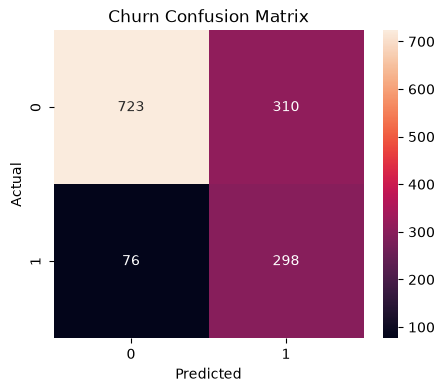

In [13]:
cm = confusion_matrix(
    y_test,
    prediction
)


plt.figure(figsize=(5,4))


sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)


plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Churn Confusion Matrix"
)


plt.show()

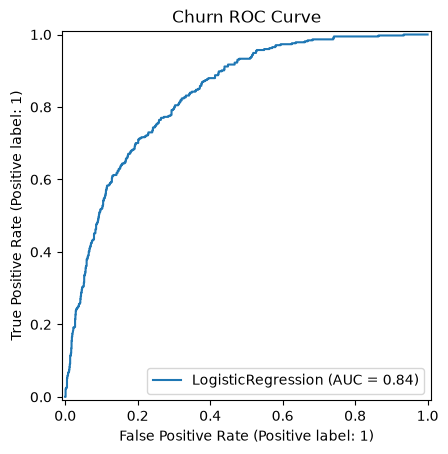

In [14]:
RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)


plt.title(
    "Churn ROC Curve"
)


plt.show()